<a href="https://colab.research.google.com/github/mthudangn/llm-therapy-fidelity/blob/experiment/thesis_pipeline.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# I. Data Exploration

In [2]:
from google.colab import files

uploaded = files.upload()

Saving AnnoMI-full.csv to AnnoMI-full (1).csv


## 1.1. Import libraries and load dataset

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

In [4]:
DATA_PATH = "AnnoMI-full.csv"

df = pd.read_csv(DATA_PATH)

print("Dataset shape:", df.shape)
df.head()

Dataset shape: (13551, 18)


,mi_quality,transcript_id,video_title,video_url,topic,utterance_id,interlocutor,timestamp,utterance_text,annotator_id,therapist_input_exists,therapist_input_subtype,reflection_exists,reflection_subtype,question_exists,question_subtype,main_therapist_behaviour,client_talk_type
0,high,0,"NEW VIDEO: Brief intervention: ""Barbara""",https://www.youtube.com/watch?v=PaSKcfTmFEk,reducing alcohol consumption,0,therapist,00:00:13,Thanks for filling it out. We give this form t...,3,False,NaN,False,NaN,True,open,question,NaN
1,high,0,"NEW VIDEO: Brief intervention: ""Barbara""",https://www.youtube.com/watch?v=PaSKcfTmFEk,reducing alcohol consumption,1,client,00:00:24,Sure.,3,NaN,NaN,NaN,NaN,NaN,NaN,NaN,neutral
2,high,0,"NEW VIDEO: Brief intervention: ""Barbara""",https://www.youtube.com/watch?v=PaSKcfTmFEk,reducing alcohol consumption,2,therapist,00:00:25,"So, let's see. It looks that you put-- You dri...",3,True,information,False,NaN,False,NaN,therapist_input,NaN
3,high,0,"NEW VIDEO: Brief intervention: ""Barbara""",https://www.youtube.com/watch?v=PaSKcfTmFEk,reducing alcohol consumption,3,client,00:00:34,Mm-hmm.,3,NaN,NaN,NaN,NaN,NaN,NaN,NaN,neutral
4,high,0,"NEW VIDEO: Brief intervention: ""Barbara""",https://www.youtube.com/watch?v=PaSKcfTmFEk,reducing alcohol consumption,4,therapist,00:00:34,-and you usually have three to four drinks whe...,3,True,information,False,NaN,False,NaN,therapist_input,NaN


## 1.2. Inspect data

In [5]:
print("Columns:")
print(df.columns.tolist())
print("\nData types:")
print(df.dtypes)
print("\nMissing values:")
print(df.isna().sum())

Columns:
['mi_quality', 'transcript_id', 'video_title', 'video_url', 'topic', 'utterance_id', 'interlocutor', 'timestamp', 'utterance_text', 'annotator_id', 'therapist_input_exists', 'therapist_input_subtype', 'reflection_exists', 'reflection_subtype', 'question_exists', 'question_subtype', 'main_therapist_behaviour', 'client_talk_type']

Data types:
mi_quality                  object
transcript_id                int64
video_title                 object
video_url                   object
topic                       object
utterance_id                 int64
interlocutor                object
timestamp                   object
utterance_text              object
annotator_id                 int64
therapist_input_exists      object
therapist_input_subtype     object
reflection_exists           object
reflection_subtype          object
question_exists             object
question_subtype            object
main_therapist_behaviour    object
client_talk_type            object
dtype: object

Mi

In [6]:
display(df.sample(min(5, len(df)), random_state=42))

,mi_quality,transcript_id,video_title,video_url,topic,utterance_id,interlocutor,timestamp,utterance_text,annotator_id,therapist_input_exists,therapist_input_subtype,reflection_exists,reflection_subtype,question_exists,question_subtype,main_therapist_behaviour,client_talk_type
811,high,7,Doctor Uses Motivational Interviewing to Discu...,https://www.youtube.com/watch?v=_HpKn29oCD0,reducing alcohol consumption,35,client,00:03:38,"Uh, uh I would say a little over that.",3,NaN,NaN,NaN,NaN,NaN,NaN,NaN,neutral
13474,low,131,Stop smoking - initial consultation,https://www.youtube.com/watch?v=pL3zIl2hS-o,smoking cessation,14,therapist,00:01:02,How much does it actually cost you a week?,9,False,NaN,False,NaN,True,closed,question,NaN
12503,low,27,How NOT to do Motivational Interviewing: A con...,https://www.youtube.com/watch?v=kN7T-cmb_l0,asthma management,12,therapist,00:01:17,"-and you are very concerned about your health,...",7,False,NaN,False,NaN,False,NaN,other,NaN
8457,high,88,MI-Change Plan,https://www.youtube.com/watch?v=DYQ6KVWv5xU,compliance with rules,31,therapist,00:02:41,When would be a great day for you to start this?,9,True,negotiation,False,NaN,True,closed,question,NaN
6415,high,62,EPE Role Play,https://www.youtube.com/watch?v=31r4rCwoa_o,completion of community service,40,client,00:02:52,I think that's it. I think I was just worried ...,8,NaN,NaN,NaN,NaN,NaN,NaN,NaN,change


In [7]:
candidate_cols = [
    "transcript_id",
    "utterance_id",
    "interlocutor",
    "utterance_text",
    "main_therapist_behaviour",
    "client_talk_type",
    "mi_quality",
    "question_exists",
    "question_subtype",
    "reflection_exists",
    "reflection_subtype",
    "therapist_input_subtype"
]

existing_cols = [c for c in candidate_cols if c in df.columns]

print("Existing key columns:")
for c in existing_cols:
    print("-", c)


Existing key columns:
- transcript_id
- utterance_id
- interlocutor
- utterance_text
- main_therapist_behaviour
- client_talk_type
- mi_quality
- question_exists
- question_subtype
- reflection_exists
- reflection_subtype
- therapist_input_subtype


## 1.3. Value counts for important categorical columns, including subtype columns

In [8]:
for col in [
    "interlocutor",
    "main_therapist_behaviour",
    "client_talk_type",
    "mi_quality",
    "question_exists",
    "question_subtype",
    "reflection_exists",
    "reflection_subtype",
    "therapist_input_subtype"
]:
    if col in df.columns:
        print(f"\n===== {col} =====")
        print(df[col].value_counts(dropna=False))



===== interlocutor =====
interlocutor
therapist    6826
client       6725
Name: count, dtype: int64

===== main_therapist_behaviour =====
main_therapist_behaviour
NaN                6725
other              2143
question           1954
reflection         1717
therapist_input    1012
Name: count, dtype: int64

===== client_talk_type =====
client_talk_type
NaN        6826
neutral    4217
change     1668
sustain     840
Name: count, dtype: int64

===== mi_quality =====
mi_quality
high    12286
low      1265
Name: count, dtype: int64

===== question_exists =====
question_exists
NaN      6725
False    4513
True     2313
Name: count, dtype: int64

===== question_subtype =====
question_subtype
NaN       11238
open       1340
closed      973
Name: count, dtype: int64

===== reflection_exists =====
reflection_exists
NaN      6725
False    4805
True     2021
Name: count, dtype: int64

===== reflection_subtype =====
reflection_subtype
NaN        11530
simple      1070
complex      951
Name: count

## 1.4. Data filtering

### Filter therapist utterances

In [9]:
therapist_df = df[df["interlocutor"].astype(str).str.lower() == "therapist"].copy()

print("Therapist rows shape:", therapist_df.shape)
therapist_df.head()

Therapist rows shape: (6826, 18)


,mi_quality,transcript_id,video_title,video_url,topic,utterance_id,interlocutor,timestamp,utterance_text,annotator_id,therapist_input_exists,therapist_input_subtype,reflection_exists,reflection_subtype,question_exists,question_subtype,main_therapist_behaviour,client_talk_type
0,high,0,"NEW VIDEO: Brief intervention: ""Barbara""",https://www.youtube.com/watch?v=PaSKcfTmFEk,reducing alcohol consumption,0,therapist,00:00:13,Thanks for filling it out. We give this form t...,3,False,NaN,False,NaN,True,open,question,NaN
2,high,0,"NEW VIDEO: Brief intervention: ""Barbara""",https://www.youtube.com/watch?v=PaSKcfTmFEk,reducing alcohol consumption,2,therapist,00:00:25,"So, let's see. It looks that you put-- You dri...",3,True,information,False,NaN,False,NaN,therapist_input,NaN
4,high,0,"NEW VIDEO: Brief intervention: ""Barbara""",https://www.youtube.com/watch?v=PaSKcfTmFEk,reducing alcohol consumption,4,therapist,00:00:34,-and you usually have three to four drinks whe...,3,True,information,False,NaN,False,NaN,therapist_input,NaN
6,high,0,"NEW VIDEO: Brief intervention: ""Barbara""",https://www.youtube.com/watch?v=PaSKcfTmFEk,reducing alcohol consumption,6,therapist,00:00:42,Okay. That's at least 12 drinks a week.,3,True,information,False,NaN,False,NaN,therapist_input,NaN
8,high,0,"NEW VIDEO: Brief intervention: ""Barbara""",https://www.youtube.com/watch?v=PaSKcfTmFEk,reducing alcohol consumption,8,therapist,00:00:47,"Okay. Just so you know, my role, um, when we t...",3,True,information,False,NaN,False,NaN,therapist_input,NaN


### Keep only rows with therapist text and therapist label

In [10]:
therapist_df = therapist_df.dropna(subset=["utterance_text", "main_therapist_behaviour"]).copy()

print("Therapist rows with text + label:", therapist_df.shape)
print("\nTherapist behaviour labels:")
print(therapist_df["main_therapist_behaviour"].value_counts())

Therapist rows with text + label: (6826, 18)

Therapist behaviour labels:
main_therapist_behaviour
other              2143
question           1954
reflection         1717
therapist_input    1012
Name: count, dtype: int64


### Basic text cleaning

In [11]:
therapist_df["utterance_text"] = (
    therapist_df["utterance_text"]
    .astype(str)
    .str.strip()
    .str.replace(r"\s+", " ", regex=True)
)

therapist_df = therapist_df[therapist_df["utterance_text"] != ""].copy()

print("After text cleaning:", therapist_df.shape)
therapist_df[["utterance_text", "main_therapist_behaviour"]].head(10)

After text cleaning: (6826, 18)


,utterance_text,main_therapist_behaviour
0,Thanks for filling it out. We give this form t...,question
2,"So, let's see. It looks that you put-- You dri...",therapist_input
4,-and you usually have three to four drinks whe...,therapist_input
6,Okay. That's at least 12 drinks a week.,therapist_input
8,"Okay. Just so you know, my role, um, when we t...",therapist_input
10,"Uh, what else can you tell me about your drink...",question
12,"Okay. So, can I share with you some informatio...",question
14,"Okay. So, there has been a lot of research on ...",therapist_input
16,Seven.,therapist_input
18,"Yeah, you're surprised to hear that?",question


## 1.5. Data inspection

### Class distribution plot

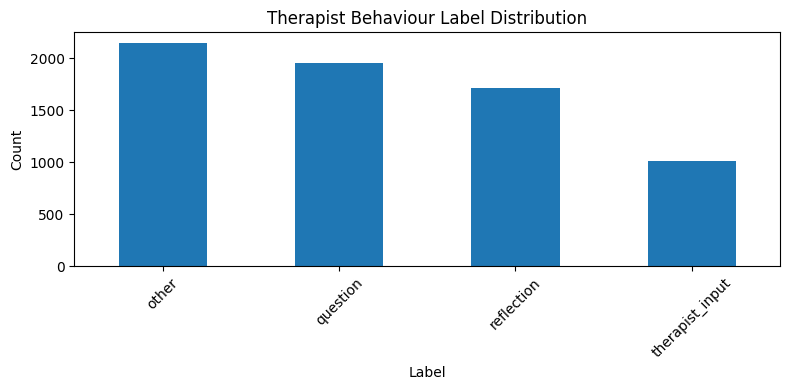

In [12]:
label_counts = therapist_df["main_therapist_behaviour"].value_counts().sort_values(ascending=False)

plt.figure(figsize=(8, 4))
label_counts.plot(kind="bar")
plt.title("Therapist Behaviour Label Distribution")
plt.xlabel("Label")
plt.ylabel("Count")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

### Inspect transcript-level MI quality

In [13]:
if "mi_quality" in therapist_df.columns:
    print(therapist_df[["transcript_id", "mi_quality"]].drop_duplicates()["mi_quality"].value_counts(dropna=False))

mi_quality
high    110
low      23
Name: count, dtype: int64


### Examples from each therapist behaviour class





In [14]:
labels = therapist_df["main_therapist_behaviour"].dropna().unique().tolist()

for label in sorted(labels):
    print(f"\n===== Examples: {label} =====")
    sample_rows = therapist_df[therapist_df["main_therapist_behaviour"] == label][["utterance_text"]].head(5)
    for i, txt in enumerate(sample_rows["utterance_text"], 1):
        print(f"{i}. {txt}")


===== Examples: other =====
1. Great. So, let's see how well you're doing with these new meds.
2. Okay.
3. Okay. Good.
4. Hi, Emily.
5. It's been a while.

===== Examples: question =====
1. Thanks for filling it out. We give this form to everyone once a year regardless of why they come in. It helps us provide better care. Is it okay if I take a look at what you put down?
2. Uh, what else can you tell me about your drinking.
3. Okay. So, can I share with you some information on alcohol use?
4. Yeah, you're surprised to hear that?
5. Well, how do you think your drinking relates to the depression you've experienced?

===== Examples: reflection =====
1. Right. By the way, binge drinking is defined for women as having more than, uh, three drinks and there are about five drinks in a bottle. So, you enjoy drinking wine because it helps make things, uh, a little bit more interesting when you're feeling down but at the same time you don't like drinking when you have more than you want it to an

## 1.6. Create modelling dataframe

A compact dataframe keeps subtype columns for later fidelity analysis

In [15]:
keep_cols = [
    "transcript_id",
    "utterance_text",
    "main_therapist_behaviour",
    "question_exists",
    "question_subtype",
    "reflection_exists",
    "reflection_subtype",
    "therapist_input_subtype",
    "mi_quality"
]

existing_keep_cols = [c for c in keep_cols if c in therapist_df.columns]

model_df = therapist_df[existing_keep_cols].copy()

model_df = model_df.rename(columns={
    "utterance_text": "text",
    "main_therapist_behaviour": "label"
})

print("Model dataframe shape:", model_df.shape)
display(model_df.head())


Model dataframe shape: (6826, 9)


,transcript_id,text,label,question_exists,question_subtype,reflection_exists,reflection_subtype,therapist_input_subtype,mi_quality
0,0,Thanks for filling it out. We give this form t...,question,True,open,False,NaN,NaN,high
2,0,"So, let's see. It looks that you put-- You dri...",therapist_input,False,NaN,False,NaN,information,high
4,0,-and you usually have three to four drinks whe...,therapist_input,False,NaN,False,NaN,information,high
6,0,Okay. That's at least 12 drinks a week.,therapist_input,False,NaN,False,NaN,information,high
8,0,"Okay. Just so you know, my role, um, when we t...",therapist_input,False,NaN,False,NaN,information,high


In [16]:
print("Unique labels:", sorted(model_df["label"].unique().tolist()))
print("\nNumber of transcripts:", model_df["transcript_id"].nunique())
print("Number of utterances:", len(model_df))
print("\nNulls:")
print(model_df.isna().sum())

Unique labels: ['other', 'question', 'reflection', 'therapist_input']

Number of transcripts: 133
Number of utterances: 6826

Nulls:
transcript_id                 0
text                          0
label                         0
question_exists               0
question_subtype           4513
reflection_exists             0
reflection_subtype         4805
therapist_input_subtype    5610
mi_quality                    0
dtype: int64


In [17]:
output_path = "therapist_model_df.csv"
model_df.to_csv(output_path, index=False)

print(f"Saved cleaned file to: {output_path}")

Saved cleaned file to: therapist_model_df.csv


---

# II. Data Preprocessing

Prepare a clean therapist-utterance dataset for modelling.

In [18]:
# keep only necessary columns, including subtype columns from AnnoMI-full
keep_cols = [
    "transcript_id",
    "utterance_text",
    "main_therapist_behaviour",
    "question_exists",
    "question_subtype",
    "reflection_exists",
    "reflection_subtype",
    "therapist_input_subtype",
    "mi_quality"
]

existing_keep_cols = [c for c in keep_cols if c in therapist_df.columns]

prep_df = therapist_df[existing_keep_cols].copy()

prep_df = prep_df.rename(columns={
    "utterance_text": "text",
    "main_therapist_behaviour": "label"
})

print(prep_df.shape)
prep_df.head()


(6826, 9)


,transcript_id,text,label,question_exists,question_subtype,reflection_exists,reflection_subtype,therapist_input_subtype,mi_quality
0,0,Thanks for filling it out. We give this form t...,question,True,open,False,NaN,NaN,high
2,0,"So, let's see. It looks that you put-- You dri...",therapist_input,False,NaN,False,NaN,information,high
4,0,-and you usually have three to four drinks whe...,therapist_input,False,NaN,False,NaN,information,high
6,0,Okay. That's at least 12 drinks a week.,therapist_input,False,NaN,False,NaN,information,high
8,0,"Okay. Just so you know, my role, um, when we t...",therapist_input,False,NaN,False,NaN,information,high


## Remove missing and duplicate rows

In [19]:
prep_df = prep_df.dropna(subset=["text", "label"]).copy()
prep_df["text"] = prep_df["text"].astype(str).str.strip()
prep_df = prep_df[prep_df["text"] != ""].copy()

before_dedup = len(prep_df)
dedup_cols = [c for c in ["transcript_id", "text", "label", "question_subtype", "reflection_subtype", "therapist_input_subtype"] if c in prep_df.columns]
prep_df = prep_df.drop_duplicates(subset=dedup_cols).copy()

print("Before dedup:", before_dedup)
print("After dedup :", len(prep_df))
print("Dedup columns:", dedup_cols)


Before dedup: 6826
After dedup : 4573
Dedup columns: ['transcript_id', 'text', 'label', 'question_subtype', 'reflection_subtype', 'therapist_input_subtype']


## Normalize text

In [20]:
import re

def clean_text(text):
    text = str(text).strip()
    text = re.sub(r"\s+", " ", text)
    return text

prep_df["text"] = prep_df["text"].apply(clean_text)

prep_df.head()

,transcript_id,text,label,question_exists,question_subtype,reflection_exists,reflection_subtype,therapist_input_subtype,mi_quality
0,0,Thanks for filling it out. We give this form t...,question,True,open,False,NaN,NaN,high
2,0,"So, let's see. It looks that you put-- You dri...",therapist_input,False,NaN,False,NaN,information,high
4,0,-and you usually have three to four drinks whe...,therapist_input,False,NaN,False,NaN,information,high
6,0,Okay. That's at least 12 drinks a week.,therapist_input,False,NaN,False,NaN,information,high
8,0,"Okay. Just so you know, my role, um, when we t...",therapist_input,False,NaN,False,NaN,information,high


In [21]:
# Inspect label distribution after cleaning
label_counts = prep_df["label"].value_counts()
label_counts

,count
label,
question,1523
reflection,1405
other,894
therapist_input,751


In [22]:
# valid_labels = label_counts[label_counts >= 20].index
# prep_df = prep_df[prep_df["label"].isin(valid_labels)].copy()

# print(prep_df["label"].value_counts())

## Encode labels

In [23]:
from sklearn.preprocessing import LabelEncoder

label_encoder = LabelEncoder()
prep_df["label_id"] = label_encoder.fit_transform(prep_df["label"])

label_mapping = dict(zip(label_encoder.classes_, label_encoder.transform(label_encoder.classes_)))
print(label_mapping)

{'other': np.int64(0), 'question': np.int64(1), 'reflection': np.int64(2), 'therapist_input': np.int64(3)}


## Stratified train/validation/test split

In [24]:
from sklearn.model_selection import train_test_split

train_df, temp_df = train_test_split(
    prep_df,
    test_size=0.30,
    random_state=42,
    stratify=prep_df["label"]
)

val_df, test_df = train_test_split(
    temp_df,
    test_size=0.50,
    random_state=42,
    stratify=temp_df["label"]
)

print("Train shape:", train_df.shape)
print("Val shape  :", val_df.shape)
print("Test shape :", test_df.shape)

Train shape: (3201, 10)
Val shape  : (686, 10)
Test shape : (686, 10)


Subtype columns are carried through the split so we can reuse them later for fidelity-related metrics.

In [25]:
# Sanity check label balance across splits

print("Train label distribution:")
print(train_df["label"].value_counts(normalize=True).round(3))

print("\nValidation label distribution:")
print(val_df["label"].value_counts(normalize=True).round(3))

print("\nTest label distribution:")
print(test_df["label"].value_counts(normalize=True).round(3))

Train label distribution:
label
question           0.333
reflection         0.307
other              0.196
therapist_input    0.164
Name: proportion, dtype: float64

Validation label distribution:
label
question           0.332
reflection         0.308
other              0.195
therapist_input    0.165
Name: proportion, dtype: float64

Test label distribution:
label
question           0.334
reflection         0.308
other              0.195
therapist_input    0.163
Name: proportion, dtype: float64


In [26]:
X_train = train_df["text"].tolist()
y_train = train_df["label_id"].tolist()

X_val = val_df["text"].tolist()
y_val = val_df["label_id"].tolist()

X_test = test_df["text"].tolist()
y_test = test_df["label_id"].tolist()

print(len(X_train), len(X_val), len(X_test))

3201 686 686


In [27]:
train_df.to_csv("train_df.csv", index=False)
val_df.to_csv("val_df.csv", index=False)
test_df.to_csv("test_df.csv", index=False)

print("Saved: train_df.csv, val_df.csv, test_df.csv")

Saved: train_df.csv, val_df.csv, test_df.csv


---

# III. Baseline Models

Evaluate classical machine learning models using TF-IDF features.

In [28]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC
from sklearn.metrics import classification_report, accuracy_score

## 3.1. TF-IDF vectorization

In [29]:
tfidf = TfidfVectorizer(
    max_features=10000,
    ngram_range=(1,2),
    stop_words="english"
)

X_train_vec = tfidf.fit_transform(train_df["text"])
X_test_vec = tfidf.transform(test_df["text"])

y_train = train_df["label_id"]
y_test = test_df["label_id"]

## 3.2. Logistic Regression baseline

In [30]:
lr_model = LogisticRegression(max_iter=200)

lr_model.fit(X_train_vec, y_train)

y_pred_lr = lr_model.predict(X_test_vec)

print("Logistic Regression Accuracy:")
print(accuracy_score(y_test, y_pred_lr))

print("\nClassification Report:")
print(classification_report(y_test, y_pred_lr))

Logistic Regression Accuracy:
0.5597667638483965

Classification Report:
              precision    recall  f1-score   support

           0       0.69      0.57      0.63       134
           1       0.53      0.65      0.58       229
           2       0.53      0.58      0.55       211
           3       0.54      0.33      0.41       112

    accuracy                           0.56       686
   macro avg       0.57      0.53      0.54       686
weighted avg       0.57      0.56      0.56       686



## 3.3. Linear SVM baseline

In [31]:
svm_model = LinearSVC()

svm_model.fit(X_train_vec, y_train)

y_pred_svm = svm_model.predict(X_test_vec)

print("Linear SVM Accuracy:")
print(accuracy_score(y_test, y_pred_svm))

print("\nClassification Report:")
print(classification_report(y_test, y_pred_svm))

Linear SVM Accuracy:
0.5714285714285714

Classification Report:
              precision    recall  f1-score   support

           0       0.64      0.64      0.64       134
           1       0.56      0.59      0.58       229
           2       0.56      0.57      0.57       211
           3       0.54      0.44      0.48       112

    accuracy                           0.57       686
   macro avg       0.57      0.56      0.57       686
weighted avg       0.57      0.57      0.57       686



## 3.4. Model Comparison

In [32]:
lr_acc = accuracy_score(y_test, y_pred_lr)
svm_acc = accuracy_score(y_test, y_pred_svm)

print("Model comparison:")
print("Logistic Regression:", lr_acc)
print("Linear SVM:", svm_acc)

Model comparison:
Logistic Regression: 0.5597667638483965
Linear SVM: 0.5714285714285714


---

# IV. LLM-based Fidelity Classification

This section evaluates an embedding-based approach using Sentence-BERT representations of therapist utterances. These dense semantic embeddings are used as inputs to downstream classifiers for therapist behaviour prediction.

In [33]:
!pip -q install sentence-transformers

In [34]:
from sentence_transformers import SentenceTransformer
from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC
from sklearn.metrics import accuracy_score, classification_report

## 4.1. Load embedding model and encode text

In [35]:
# Load embedding model
sbert_model = SentenceTransformer("all-MiniLM-L6-v2")

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/116 [00:00<?, ?B/s]

README.md: 0.00B [00:00, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

...

tokenizer_config.json:   0%|          | 0.00/350 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

In [36]:
# Encode text

X_train_emb = sbert_model.encode(
    train_df["text"].tolist(),
    batch_size=32,
    show_progress_bar=True
)

X_test_emb = sbert_model.encode(
    test_df["text"].tolist(),
    batch_size=32,
    show_progress_bar=True
)

y_train = train_df["label_id"].values
y_test = test_df["label_id"].values

print("Train embeddings shape:", X_train_emb.shape)
print("Test embeddings shape :", X_test_emb.shape)

Batches:   0%|          | 0/101 [00:00<?, ?it/s]

Batches:   0%|          | 0/22 [00:00<?, ?it/s]

Train embeddings shape: (3201, 384)
Test embeddings shape : (686, 384)


## 4.2. SBERT + Logistic Regression

In [37]:
sbert_lr = LogisticRegression(max_iter=500)

sbert_lr.fit(X_train_emb, y_train)

y_pred_sbert_lr = sbert_lr.predict(X_test_emb)

print("SBERT + Logistic Regression Accuracy:")
print(accuracy_score(y_test, y_pred_sbert_lr))

print("\nClassification Report:")
print(classification_report(y_test, y_pred_sbert_lr, target_names=label_encoder.classes_))

SBERT + Logistic Regression Accuracy:
0.6865889212827988

Classification Report:
                 precision    recall  f1-score   support

          other       0.80      0.64      0.71       134
       question       0.74      0.78      0.76       229
     reflection       0.64      0.69      0.66       211
therapist_input       0.55      0.54      0.55       112

       accuracy                           0.69       686
      macro avg       0.68      0.66      0.67       686
   weighted avg       0.69      0.69      0.69       686



## 4.3. SBERT + Linear SVM

In [38]:
sbert_svm = LinearSVC()

sbert_svm.fit(X_train_emb, y_train)

y_pred_sbert_svm = sbert_svm.predict(X_test_emb)

print("SBERT + Linear SVM Accuracy:")
print(accuracy_score(y_test, y_pred_sbert_svm))

print("\nClassification Report:")
print(classification_report(y_test, y_pred_sbert_svm, target_names=label_encoder.classes_))

SBERT + Linear SVM Accuracy:
0.6997084548104956

Classification Report:
                 precision    recall  f1-score   support

          other       0.82      0.66      0.73       134
       question       0.76      0.78      0.77       229
     reflection       0.66      0.71      0.68       211
therapist_input       0.54      0.56      0.55       112

       accuracy                           0.70       686
      macro avg       0.70      0.68      0.68       686
   weighted avg       0.71      0.70      0.70       686



In [39]:
results = {
    "TF-IDF + Logistic Regression": accuracy_score(y_test, y_pred_lr),
    "TF-IDF + Linear SVM": accuracy_score(y_test, y_pred_svm),
    "SBERT + Logistic Regression": accuracy_score(y_test, y_pred_sbert_lr),
    "SBERT + Linear SVM": accuracy_score(y_test, y_pred_sbert_svm),
}

print("Model Comparison")
for model_name, acc in results.items():
    print(f"{model_name}: {acc:.4f}")

best_model_name = max(results, key=results.get)
print("\nBest model:", best_model_name)

if best_model_name == "TF-IDF + Logistic Regression":
    best_pred = y_pred_lr
elif best_model_name == "TF-IDF + Linear SVM":
    best_pred = y_pred_svm
elif best_model_name == "SBERT + Logistic Regression":
    best_pred = y_pred_sbert_lr
else:
    best_pred = y_pred_sbert_svm

Model Comparison
TF-IDF + Logistic Regression: 0.5598
TF-IDF + Linear SVM: 0.5714
SBERT + Logistic Regression: 0.6866
SBERT + Linear SVM: 0.6997

Best model: SBERT + Linear SVM


In [40]:
results = {
    "TF-IDF + Logistic Regression": accuracy_score(y_test, y_pred_lr),
    "TF-IDF + Linear SVM": accuracy_score(y_test, y_pred_svm),
    "SBERT + Logistic Regression": accuracy_score(y_test, y_pred_sbert_lr),
    "SBERT + Linear SVM": accuracy_score(y_test, y_pred_sbert_svm),
}

print("Model Comparison")
for model_name, acc in results.items():
    print(f"{model_name}: {acc:.4f}")

Model Comparison
TF-IDF + Logistic Regression: 0.5598
TF-IDF + Linear SVM: 0.5714
SBERT + Logistic Regression: 0.6866
SBERT + Linear SVM: 0.6997


In [41]:
# Results table
results_df = pd.DataFrame({
    "Model": list(results.keys()),
    "Accuracy": list(results.values())
}).sort_values("Accuracy", ascending=False)

results_df

,Model,Accuracy
3,SBERT + Linear SVM,0.699708
2,SBERT + Logistic Regression,0.686589
1,TF-IDF + Linear SVM,0.571429
0,TF-IDF + Logistic Regression,0.559767


In [42]:
# Save results
results_df.to_csv("baseline_vs_sbert_results.csv", index=False)
print("Saved: baseline_vs_sbert_results.csv")

Saved: baseline_vs_sbert_results.csv


---

# V. Evaluation and Error Analysis

This section evaluates model performance in more detail using confusion matrices and per-class metrics.
We also inspect misclassified therapist utterances to better understand model limitations.

In [43]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test, best_pred)

plt.figure(figsize=(6,5))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    xticklabels=label_encoder.classes_,
    yticklabels=label_encoder.classes_,
    cmap="Blues"
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title(f"Confusion Matrix: {best_model_name}")
plt.show()


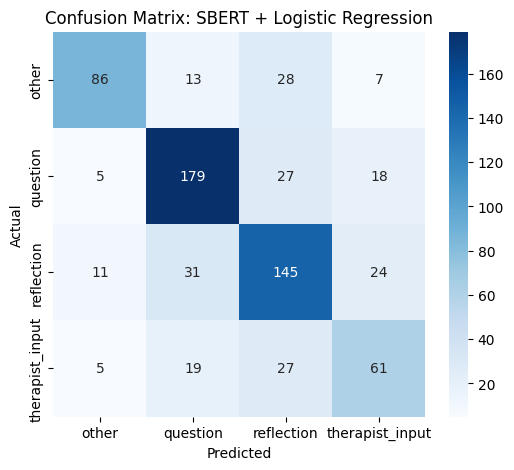

In [44]:
# Pick the best performing model from Part IV

cm = confusion_matrix(y_test, y_pred_sbert_lr)

plt.figure(figsize=(6,5))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    xticklabels=label_encoder.classes_,
    yticklabels=label_encoder.classes_,
    cmap="Blues"
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix: SBERT + Logistic Regression")
plt.show()

## 5.2. Classification report table

In [45]:
from sklearn.metrics import classification_report
import pandas as pd

report = classification_report(
    y_test,
    y_pred_sbert_lr,
    target_names=label_encoder.classes_,
    output_dict=True
)
report_df = pd.DataFrame(report).transpose()
report_df

,precision,recall,f1-score,support
other,0.803738,0.641791,0.713693,134.000000
question,0.739669,0.781659,0.760085,229.000000
reflection,0.638767,0.687204,0.662100,211.000000
therapist_input,0.554545,0.544643,0.549550,112.000000
accuracy,0.686589,0.686589,0.686589,0.686589
macro avg,0.684180,0.663824,0.671357,686.000000
weighted avg,0.690924,0.686589,0.686512,686.000000


In [46]:
# # Save evaluation results
# report_df.to_csv("classification_report_sbert_lr.csv")
# print("Saved evaluation report")

In [51]:
test_df = test_df.copy()
test_df["pred_label_id"] = best_pred
test_df["pred_label"] = label_encoder.inverse_transform(test_df["pred_label_id"])
test_df["true_label_id"] = test_df["label_id"]
test_df["true_label"] = test_df["label"]

errors_df = test_df[test_df["true_label"] != test_df["pred_label"]].copy()

print("Number of errors:", len(errors_df))
display(errors_df.head(10))


Number of errors: 206


,transcript_id,text,label,question_exists,question_subtype,reflection_exists,reflection_subtype,therapist_input_subtype,mi_quality,label_id,pred_label_id,pred_label,true_label_id,true_label
13218,126,"Hello, Kaylie. I'm Lori, the pharmacist here a...",question,True,closed,True,simple,NaN,low,1,3,therapist_input,1,question
2022,28,-and model for your- for your daughter who's a...,reflection,False,NaN,True,complex,NaN,high,2,3,therapist_input,2,reflection
6977,66,Yeah. 'Cause it looks like you need to just ta...,reflection,False,NaN,True,simple,advice,high,2,3,therapist_input,2,reflection
197,4,"-the-the piercing might not last forever, but ...",reflection,False,NaN,True,simple,advice,high,2,3,therapist_input,2,reflection
6361,61,And that you're wanting to give tai chi anothe...,reflection,False,NaN,True,simple,NaN,high,2,3,therapist_input,2,reflection
12778,44,And then-,other,False,NaN,False,NaN,NaN,low,0,2,reflection,0,other
4747,56,-might have probably helped you break your fal...,therapist_input,False,NaN,True,complex,information,high,3,2,reflection,3,therapist_input
10895,117,"Oh, this is the first time anything like this ...",question,True,open,False,NaN,NaN,high,1,3,therapist_input,1,question
6173,60,Okay. Do your homework.,reflection,False,NaN,True,complex,NaN,high,2,1,question,2,reflection
80,1,"So, on one hand, you like how beer tastes, uh,...",reflection,False,NaN,True,complex,NaN,high,2,1,question,2,reflection


In [53]:
test_df = test_df.copy()
test_df["pred_label_id"] = y_pred_sbert_lr
test_df["pred_label"] = label_encoder.inverse_transform(test_df["pred_label_id"])

errors_df = test_df[test_df["label"] != test_df["pred_label"]]

print("Number of errors:", len(errors_df))
errors_df.head(10)

Number of errors: 215


,transcript_id,text,label,question_exists,question_subtype,reflection_exists,reflection_subtype,therapist_input_subtype,mi_quality,label_id,pred_label_id,pred_label,true_label_id,true_label
13390,130,There's other ways to relax. There's yoga. The...,therapist_input,False,NaN,False,NaN,advice,low,3,2,reflection,3,therapist_input
13218,126,"Hello, Kaylie. I'm Lori, the pharmacist here a...",question,True,closed,True,simple,NaN,low,1,3,therapist_input,1,question
2022,28,-and model for your- for your daughter who's a...,reflection,False,NaN,True,complex,NaN,high,2,3,therapist_input,2,reflection
6977,66,Yeah. 'Cause it looks like you need to just ta...,reflection,False,NaN,True,simple,advice,high,2,3,therapist_input,2,reflection
11555,121,It's just tweaking things. Just fine-tuning a ...,reflection,False,NaN,True,complex,NaN,high,2,3,therapist_input,2,reflection
197,4,"-the-the piercing might not last forever, but ...",reflection,False,NaN,True,simple,advice,high,2,0,other,2,reflection
6361,61,And that you're wanting to give tai chi anothe...,reflection,False,NaN,True,simple,NaN,high,2,3,therapist_input,2,reflection
12778,44,And then-,other,False,NaN,False,NaN,NaN,low,0,2,reflection,0,other
4747,56,-might have probably helped you break your fal...,therapist_input,False,NaN,True,complex,information,high,3,2,reflection,3,therapist_input
6173,60,Okay. Do your homework.,reflection,False,NaN,True,complex,NaN,high,2,1,question,2,reflection


In [54]:
# Show error examples
for i, row in errors_df.sample(10, random_state=42).iterrows():
    print("TEXT:", row["text"])
    print("TRUE:", row["label"])
    print("PRED:", row["pred_label"])
    print("-"*60)

TEXT: -they are so, um, they are so prejudicial. They really are. And I would check with the ACLU too. I mean, just as I-I don't know much, and now I'm very curious and I wanna find out about it myself, but yeah.
TRUE: therapist_input
PRED: question
------------------------------------------------------------
TEXT: Yeah, you know, I'm concerned bout it too and I'd actually recommend that you stop using Methamphetamine altogether. And, um, there-there are a lot of reasons for this but that's-that's would be my recommendation.
TRUE: therapist_input
PRED: reflection
------------------------------------------------------------
TEXT: Generally, it works well if you find a time when you're not under a huge amount of other stresses and strains.
TRUE: therapist_input
PRED: reflection
------------------------------------------------------------
TEXT: And let's talk some more about wine. You keep throwing wine into the conversation. It sounds like it's become a significant part of your daily rou

In [55]:
# Class-wise error counts
errors_df["label"].value_counts()

,count
label,
reflection,66
therapist_input,51
question,50
other,48


# VI. Session-level Fidelity Analysis

Transcript utterance → Behaviour distribution → Subtype metrics → Session-level fidelity score

This section uses the **AnnoMI-full** subtype columns to move beyond plain behaviour classification.


## 6.1. Build utterance-level results table from the held-out test set

In [56]:
subtype_cols = [
    "question_exists",
    "question_subtype",
    "reflection_exists",
    "reflection_subtype",
    "therapist_input_subtype",
    "mi_quality"
]
existing_subtype_cols = [c for c in subtype_cols if c in test_df.columns]

results_df = test_df[["transcript_id", "text", "true_label", "pred_label"] + existing_subtype_cols].copy()

# helper: safe string normalization
def _norm_str(x):
    if pd.isna(x):
        return ""
    return str(x).strip().lower()

# create boolean flags from full annotation columns
if "question_subtype" in results_df.columns:
    results_df["is_open_question"] = results_df["question_subtype"].apply(lambda x: "open" in _norm_str(x))
    results_df["is_closed_question"] = results_df["question_subtype"].apply(lambda x: "closed" in _norm_str(x))
elif "question_exists" in results_df.columns:
    results_df["is_open_question"] = False
    results_df["is_closed_question"] = results_df["question_exists"].astype(str).str.lower().isin(["1", "true", "yes"])

if "reflection_subtype" in results_df.columns:
    results_df["is_simple_reflection"] = results_df["reflection_subtype"].apply(lambda x: "simple" in _norm_str(x))
    results_df["is_complex_reflection"] = results_df["reflection_subtype"].apply(lambda x: "complex" in _norm_str(x))
elif "reflection_exists" in results_df.columns:
    results_df["is_simple_reflection"] = results_df["reflection_exists"].astype(str).str.lower().isin(["1", "true", "yes"])
    results_df["is_complex_reflection"] = False

if "therapist_input_subtype" in results_df.columns:
    results_df["is_advice"] = results_df["therapist_input_subtype"].apply(lambda x: "advice" in _norm_str(x))
else:
    results_df["is_advice"] = False

results_df.head()


,transcript_id,text,true_label,pred_label,question_exists,question_subtype,reflection_exists,reflection_subtype,therapist_input_subtype,mi_quality,is_open_question,is_closed_question,is_simple_reflection,is_complex_reflection,is_advice
13390,130,There's other ways to relax. There's yoga. The...,therapist_input,reflection,False,NaN,False,NaN,advice,low,False,False,False,False,True
13218,126,"Hello, Kaylie. I'm Lori, the pharmacist here a...",question,therapist_input,True,closed,True,simple,NaN,low,False,True,True,False,False
1038,7,"I'd love to, uh, set up an appointment for you...",therapist_input,therapist_input,False,NaN,False,NaN,options,high,False,False,False,False,False
2022,28,-and model for your- for your daughter who's a...,reflection,therapist_input,False,NaN,True,complex,NaN,high,False,False,False,True,False
1118,8,"So, what brings you here, Bob? What's, what ca...",question,question,True,open,False,NaN,NaN,high,True,False,False,False,False


## 6.2. Compute behaviour distribution per session

In [57]:
# predicted behaviour counts per transcript
session_pred_counts = results_df.groupby(["transcript_id", "pred_label"]).size().unstack(fill_value=0)

# predicted behaviour ratios
session_pred_ratios = session_pred_counts.div(session_pred_counts.sum(axis=1), axis=0)

# gold behaviour counts per transcript (useful for reference / discussion)
session_true_counts = results_df.groupby(["transcript_id", "true_label"]).size().unstack(fill_value=0)
session_true_ratios = session_true_counts.div(session_true_counts.sum(axis=1), axis=0)

print("Predicted session behaviour table shape:", session_pred_ratios.shape)
display(session_pred_ratios.head())

Predicted session behaviour table shape: (119, 4)


pred_label,other,question,reflection,therapist_input
transcript_id,,,,
0,0.000000,0.600000,0.4,0.000000
1,0.000000,1.000000,0.0,0.000000
2,0.000000,0.750000,0.0,0.250000
3,0.500000,0.000000,0.5,0.000000
4,0.333333,0.333333,0.0,0.333333


## 6.3. Create subtype-based fidelity metrics from AnnoMI-full

In [58]:
session_metrics = results_df.groupby("transcript_id").agg(
    total_utterances=("text", "size"),
    open_questions=("is_open_question", "sum"),
    closed_questions=("is_closed_question", "sum"),
    simple_reflections=("is_simple_reflection", "sum"),
    complex_reflections=("is_complex_reflection", "sum"),
    advice_count=("is_advice", "sum")
)

session_metrics["total_questions"] = session_metrics["open_questions"] + session_metrics["closed_questions"]
session_metrics["total_reflections"] = session_metrics["simple_reflections"] + session_metrics["complex_reflections"]

# avoid divide-by-zero with np.where
session_metrics["open_question_ratio"] = np.where(
    session_metrics["total_questions"] > 0,
    session_metrics["open_questions"] / session_metrics["total_questions"],
    0.0
)

session_metrics["complex_reflection_ratio"] = np.where(
    session_metrics["total_reflections"] > 0,
    session_metrics["complex_reflections"] / session_metrics["total_reflections"],
    0.0
)

session_metrics["reflection_to_question_ratio"] = np.where(
    session_metrics["total_questions"] > 0,
    session_metrics["total_reflections"] / session_metrics["total_questions"],
    np.nan
)

session_metrics["advice_ratio"] = np.where(
    session_metrics["total_utterances"] > 0,
    session_metrics["advice_count"] / session_metrics["total_utterances"],
    0.0
)

display(session_metrics.head())

,total_utterances,open_questions,closed_questions,simple_reflections,complex_reflections,advice_count,total_questions,total_reflections,open_question_ratio,complex_reflection_ratio,reflection_to_question_ratio,advice_ratio
transcript_id,,,,,,,,,,,,
0,5,3,0,0,1,0,3,1,1.0,1.0,0.333333,0.000000
1,1,0,0,0,1,0,0,1,0.0,1.0,NaN,0.000000
2,4,4,0,2,0,0,4,2,1.0,0.0,0.500000,0.000000
3,2,0,1,0,0,0,1,0,0.0,0.0,0.000000,0.000000
4,3,0,1,1,0,1,1,1,0.0,0.0,1.000000,0.333333


## 6.4. Fidelity scoring and interpretation

In [59]:
def compute_fidelity(row):
    score = 0

    # higher is better
    if row["open_question_ratio"] >= 0.5:
        score += 1

    # higher is better
    if row["complex_reflection_ratio"] >= 0.4:
        score += 1

    # reflections should not be much lower than questions
    if pd.notna(row["reflection_to_question_ratio"]) and row["reflection_to_question_ratio"] >= 1.0:
        score += 1

    # lower advice use is better in MI-style interactions
    if row["advice_ratio"] <= 0.2:
        score += 1

    return score

session_metrics["fidelity_score"] = session_metrics.apply(compute_fidelity, axis=1)
session_metrics["high_fidelity"] = session_metrics["fidelity_score"] >= 3

display(session_metrics.sort_values("fidelity_score", ascending=False).head())


,total_utterances,open_questions,closed_questions,simple_reflections,complex_reflections,advice_count,total_questions,total_reflections,open_question_ratio,complex_reflection_ratio,reflection_to_question_ratio,advice_ratio,fidelity_score,high_fidelity
transcript_id,,,,,,,,,,,,,,
21,10,3,1,1,3,0,4,4,0.750000,0.750000,1.000000,0.000000,4,True
33,6,2,0,0,2,1,2,2,1.000000,1.000000,1.000000,0.166667,4,True
56,23,5,1,2,9,1,6,11,0.833333,0.818182,1.833333,0.043478,4,True
38,4,1,1,0,2,0,2,2,0.500000,1.000000,1.000000,0.000000,4,True
41,10,2,1,1,2,0,3,3,0.666667,0.666667,1.000000,0.000000,4,True


In [60]:
# Optional: inspect relationship with transcript-level MI quality, if available
if "mi_quality" in results_df.columns:
    mi_by_session = (
        results_df.groupby("transcript_id")["mi_quality"]
        .agg(lambda s: s.dropna().mode().iloc[0] if not s.dropna().empty else np.nan)
        .rename("mi_quality_session")
    )

    session_metrics = session_metrics.join(mi_by_session, how="left")

    print("Fidelity score by MI quality:")
    display(session_metrics.groupby("mi_quality_session")["fidelity_score"].describe())
else:
    print("mi_quality column not available in test_df.")


Fidelity score by MI quality:


,count,mean,std,min,25%,50%,75%,max
mi_quality_session,,,,,,,,
high,102.0,2.274510,1.06387,0.0,1.0,2.0,3.0,4.0
low,17.0,1.117647,0.92752,0.0,0.0,1.0,2.0,3.0


In [62]:
# Binary classification
session_metrics["high_fidelity"] = session_metrics["fidelity_score"] >= 1

## 6.5. Thesis-ready interpretation

At this point the pipeline does two things:

1. **Utterance-level behaviour classification** using the main therapist behaviour label.  
2. **Session-level fidelity analysis** using fine-grained subtype annotations from **AnnoMI-full**.

This is a stronger thesis framing than classification alone because it connects model outputs to clinically meaningful fidelity indicators such as:
- open question ratio
- complex reflection ratio
- reflection-to-question ratio
- advice ratio
